#  Credit Risk Scoring — Home Credit Default Risk

## Project Overview
This project aims to predict whether a loan applicant will default on their loan using 
machine learning techniques. The dataset is provided by Home Credit Group and contains 
real-world financial and demographic data.

## Objectives
- Perform exploratory data analysis (EDA) to understand the data
- Preprocess and engineer features for model training
- Train and compare multiple classification models
- Interpret model decisions using SHAP values

## Dataset
- **Source:** [Home Credit Default Risk — Kaggle](https://www.kaggle.com/competitions/home-credit-default-risk)
- **Main file:** `application_train.csv` (307,511 rows × 122 columns)
- **Target variable:** `TARGET` (1 = defaulted, 0 = repaid)

## Project Structure
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Feature Engineering
4. Model Training & Evaluation
5. Model Interpretability (SHAP)

## 1. Data Loading

In this section, we load the main training dataset and take a first look at its 
shape, column types, and sample rows.

In [1]:
import os

# List of available files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/home-credit-default-risk/sample_submission.csv
/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv
/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/competitions/home-credit-default-risk/application_train.csv
/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/competitions/home-credit-default-risk/application_test.csv
/kaggle/input/competitions/home-credit-default-risk/previous_application.csv
/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv
/kaggle/input/competitions/home-credit-default-risk/bureau.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot style
plt.style.use ('seaborn-v0_8')
sns.set_palette('husl')

# Load the main training dataset
df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:\n{df["TARGET"].value_counts()}")
print(f"\nDefault rate: {df["TARGET"].mean() *100:.2f}%")
df.head()

Dataset shape: (307511, 122)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


**Key observations after loading:**
- Dataset shape: 307,511 rows × 122 columns
- Default rate: 8.07% → significant class imbalance
- Some columns contain NaN values → will be handled in preprocessing

##  2. Exploratory Data Analysis (EDA)

We analyze the dataset to understand its structure, distributions, and key patterns 
before moving on to preprocessing and modeling.

**This section covers:**
- 2.1 Target Distribution — How balanced is our dataset?
- 2.2 Missing Values — Which columns have missing data and how much?
- 2.3 Numerical Feature Distributions — How are key financial variables distributed?
- 2.4 Correlation with Target — Which features are most related to default risk?

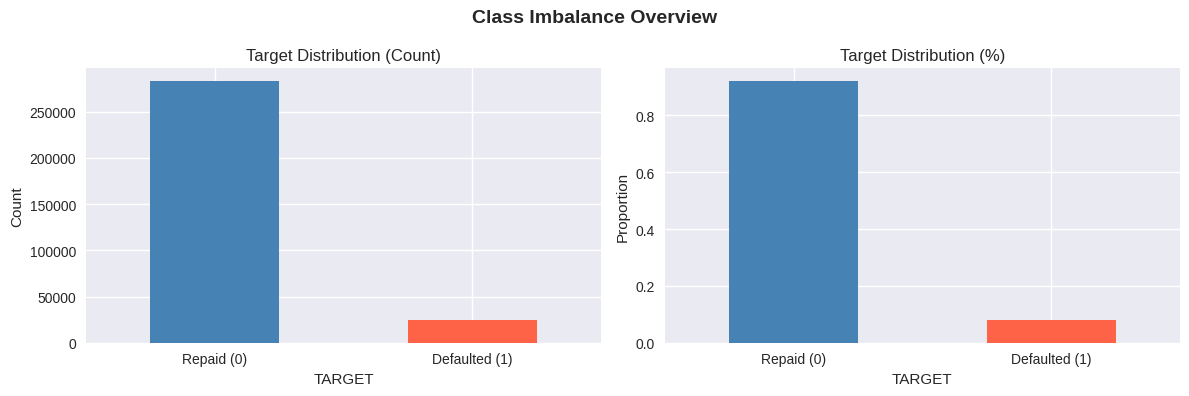

Repaid (0): 282,686 (91.93%)
Defaulted (1): 24,825 (8.07%)


In [3]:
# 2.1 Target Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['TARGET'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue', 'tomato'])
ax[0].set_title('Target Distribution (Count)')
ax[0].set_xlabel('TARGET')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['Repaid (0)', 'Defaulted (1)'], rotation=0)

# Percentage plot
df['TARGET'].value_counts(normalize=True).plot(kind='bar', ax=ax[1], color=['steelblue', 'tomato'])
ax[1].set_title('Target Distribution (%)')
ax[1].set_xlabel('TARGET')
ax[1].set_ylabel('Proportion')
ax[1].set_xticklabels(['Repaid (0)', 'Defaulted (1)'], rotation=0)

plt.suptitle('Class Imbalance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Repaid (0): {df['TARGET'].value_counts()[0]:,} ({df['TARGET'].value_counts(normalize=True)[0]*100:.2f}%)")
print(f"Defaulted (1): {df['TARGET'].value_counts()[1]:,} ({df['TARGET'].value_counts(normalize=True)[1]*100:.2f}%)")

In [10]:
# 2.2 Missing Values Analysis
def missing_values_table(df):
    # Calculate total missing values per column
    mis_val = df.isnull().sum()
    
    # Calculate percentage of missing values per column
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    
    # Create a dataframe concatenating both metrics
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1, keys=['Missing Values', '% of Total Values'])
    
    # Filter out columns with no missing values and sort by percentage descending
    mis_val_table_ren_columns = mis_val_table[
        mis_val_table.iloc[:, 1] != 0].sort_values('% of Total Values', ascending=False).round(1)
    
    # Print a summary report
    print(f"The dataframe has {df.shape[1]} columns in total.\n"
          f"There are {mis_val_table_ren_columns.shape[0]} columns that have missing values.\n")
    
    return mis_val_table_ren_columns

# Display the top 20 columns with the highest missing value percentages
missing_values_table(df).head(20)

The dataframe has 122 columns in total.
There are 67 columns that have missing values.



,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


### 2.3 Numerical Feature Distributions

We examine the distribution of key financial and demographic features to identify 
skewness, outliers, and patterns that may affect model performance.

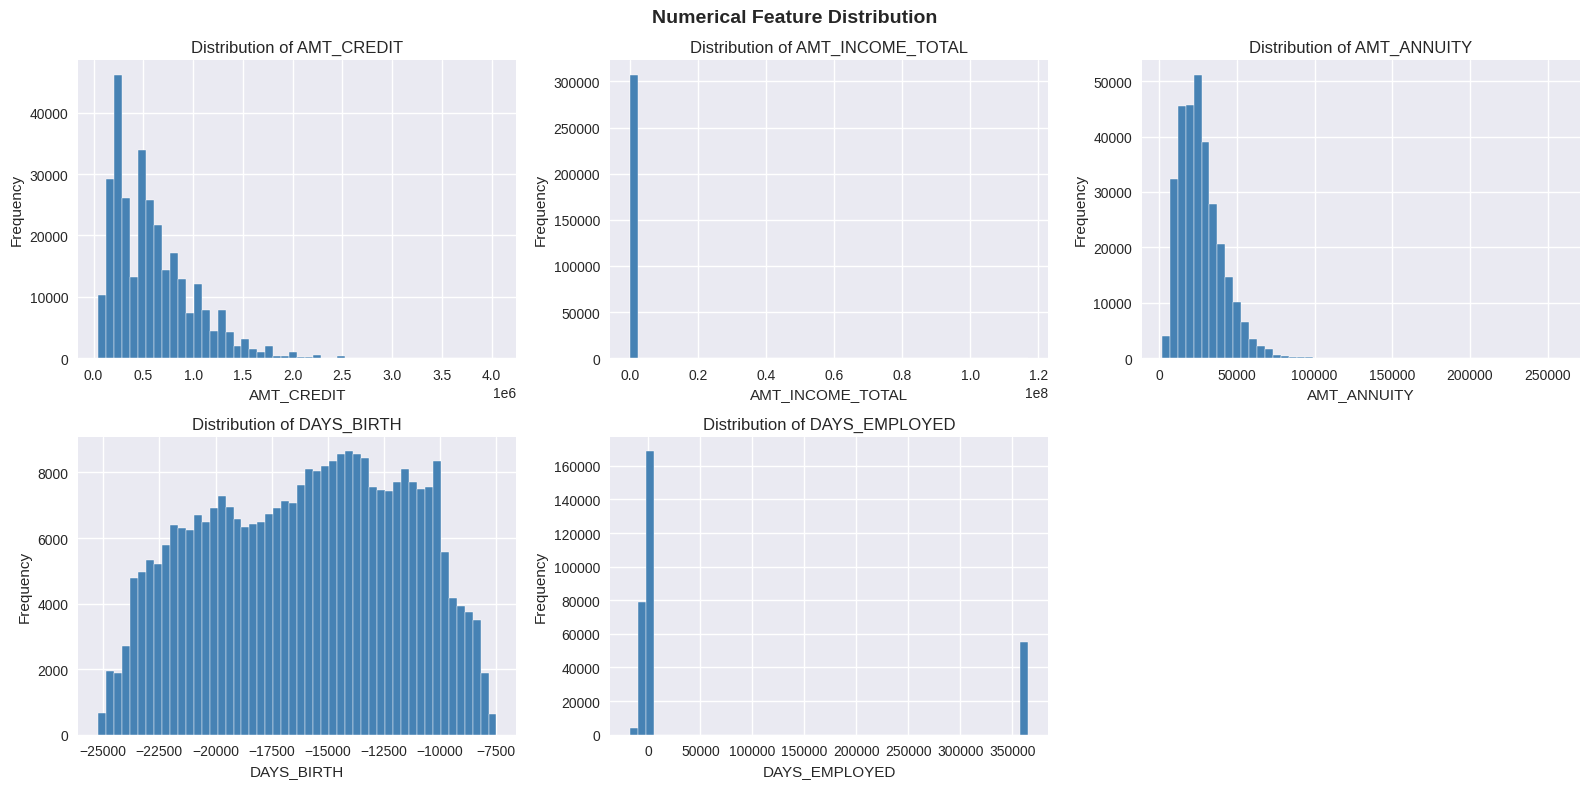

In [11]:
# 2.3 Numerical Feature Distributions
num_cols = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED']

fig, axes = plt.subplots(2,3, figsize=(16,8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins = 50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide the unused subplot
axes[-1].set_visible(False)

plt.suptitle('Numerical Feature Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Correlation with Target

We compute the correlation of each numerical feature with the target variable 
to identify which features are most predictive of loan default.

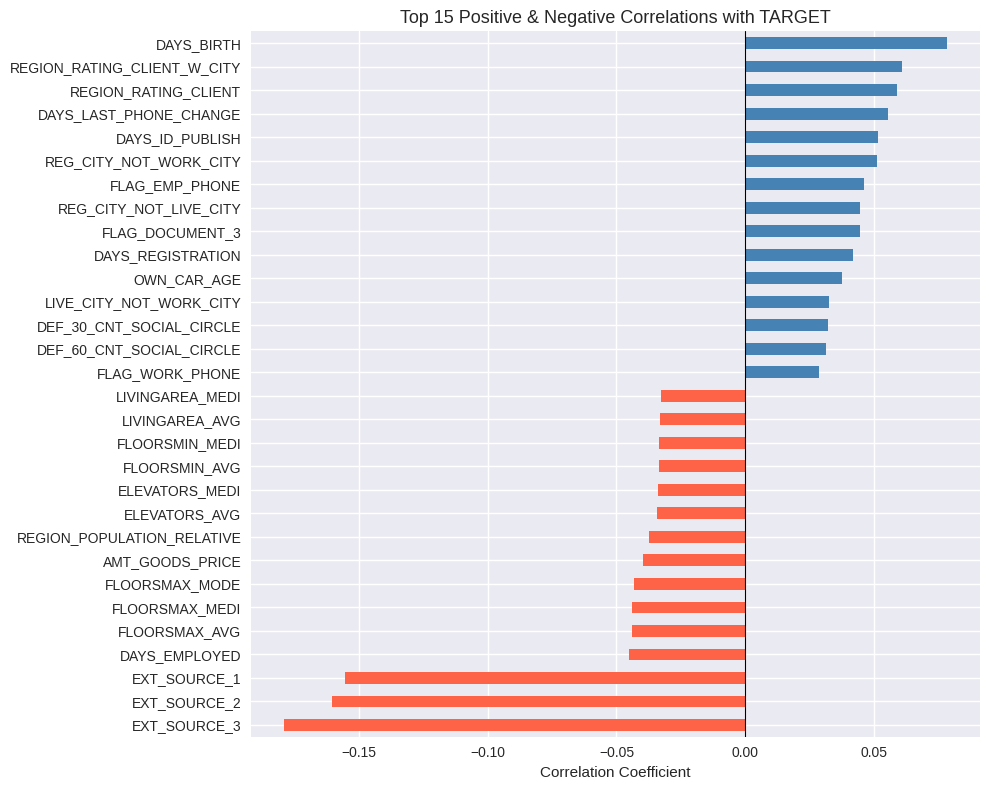

Top 10 features positively correlated with default:
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239

Top 10 features negatively correlated with default:
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199


In [14]:
# 2.4 Correlation with Target
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation with target
correlations = numeric_df.corr()['TARGET'].drop('TARGET').sort_values()

# Plot top 15 positive and negative correlations
top_corr = pd.concat([correlations.head(15), correlations.tail(15)])

plt.figure(figsize=(10,8))
top_corr.plot(kind='barh', color=['tomato' if x < 0 else 'steelblue' for x in top_corr])
plt.title('Top 15 Positive & Negative Correlations with TARGET', fontsize=13)
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Print top 10 most correlated features
print("Top 10 features positively correlated with default:")
print(correlations.tail(10).to_string())
print("\nTop 10 features negatively correlated with default:")
print(correlations.head(10).to_string())

##  3. Data Preprocessing & Feature Engineering

In this section we clean the data, handle missing values, fix anomalies, 
encode categorical variables, and engineer new features.

**This section covers:**
- 3.1 Handling Anomalies — Fix incorrect values (e.g. DAYS_EMPLOYED)
- 3.2 Feature Engineering — Create new meaningful features
- 3.3 Encoding Categorical Variables — Convert text columns to numeric
- 3.4 Handling Missing Values — Impute or drop missing data
- 3.5 Train/Validation Split — Prepare data for modeling

In [15]:
# 3.1. Handling Anomalies

# DAYS_EMPLOYED anomaly - 365243 is a placeholder for retired/unemployed people
print(f"DAYS_EMPLOYED anomalous values: {(df["DAYS_EMPLOYED"] == 365243).sum()}")

# Replace anomalous values with NaN
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

# Convert DAYS_BIRTH to age in years (positive value)
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365

# Convert DAYS_EMPLOYED to years (positive value)
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / - 365

print(f"\nAge range: {df['AGE_YEARS'].min():.1f} - {df['AGE_YEARS'].max():.1f} years")
print(f"Employment range: {df['YEARS_EMPLOYED'].min():.1f} - {df['YEARS_EMPLOYED'].max():.1f} years")

DAYS_EMPLOYED anomalous values: 55374

Age range: 20.5 - 69.1 years
Employment range: -0.0 - 49.1 years


In [16]:
# 3.2. Feature Engineering

# Credit to income ratio - how large is the loan relative to income?
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

# Annuity to income ratio - what fraction of income goes to loan payments?
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Credit Term - how many years will the loan take to repay ?
df['CREDIT_TERM'] = df['AMT_ANNUITY'] /  df['AMT_CREDIT']

# Income per family member
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df["CNT_FAM_MEMBERS"] + 1)

print('New Features created:')
print(f" CREDIT_INCOME_RATIO  - mean: {df["CREDIT_INCOME_RATIO"].mean():.2f}")
print(f"  ANNUITY_INCOME_RATIO  — mean: {df['ANNUITY_INCOME_RATIO'].mean():.2f}")
print(f"  CREDIT_TERM           — mean: {df['CREDIT_TERM'].mean():.2f}")
print(f"  INCOME_PER_PERSON     — mean: {df['INCOME_PER_PERSON'].mean():.2f}")

print(f"\nDataset shape after feature engineering: {df.shape}")


New Features created:
 CREDIT_INCOME_RATIO  - mean: 3.96
  ANNUITY_INCOME_RATIO  — mean: 0.18
  CREDIT_TERM           — mean: 0.05
  INCOME_PER_PERSON     — mean: 57482.25

Dataset shape after feature engineering: (307511, 128)


### 3.3 Encoding Categorical Variables

We convert categorical (text) columns into numeric format so that 
machine learning models can process them.

In [19]:
# 3.3. Encoding Categorical Variables

# Check categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns : {len(cat_cols)}")
print(cat_cols)

Categorical columns : 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [20]:
# Label encoding for binary columns, one-hot encoding for the rest

# Binary columns (only 2 unique values) -> Label Encoding
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
print(f"Binary columns (Label Encoding): {binary_cols}")

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Multi-class oclumns -> One-Hot Encoding
multi_cols = [col for col in cat_cols if df[col].nunique() > 2]
print(f"\Multi-class columns (One-Hot Encoding): {multi_cols}")

df = pd.get_dummies(df, columns=multi_cols)

print(f"\nDataset shape after encoding: {df.shape}")

Binary columns (Label Encoding): ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']
\Multi-class columns (One-Hot Encoding): ['CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Dataset shape after encoding: (307511, 250)


### 3.4 Handling Missing Values

We impute missing values using median for numerical columns 
and most frequent value for categorical columns.

In [21]:
# 3.4. Handling Missing Values
from sklearn.impute import SimpleImputer

print(f"Missing values before imputation: {df.isnull().sum().sum():,}")

# Seperate numeric and boolean columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target column from imputation
num_cols = [col for col in num_cols if col != 'TARGET']

# Impute numeric columns with median
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

print(f"Missing values after imputation: {df.isnull().sum().sum():,}")
print(f"\nDataset shape after imputation: {df.shape}")

Missing values before imputation: 8,498,868
Missing values after imputation: 0

Dataset shape after imputation: (307511, 250)


### 3.5 Train / Validation Split

We split the data into training and validation sets to evaluate 
model performance on unseen data.

In [22]:
# 3.5. Train / Validation Split
from sklearn.model_selection import train_test_split

# Seperate features and target
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df["TARGET"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target Distribution:\n{y.value_counts()}")

# Split - 80% train, %20 validation, stratified to preserve class balance
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"\nTrain default rate: {y_train.mean()*100:.2f}%")
print(f"Validation default rate: {y_val.mean()*100:.2f}%")

Features shape: (307511, 248)
Target shape: (307511,)
Target Distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Train set: (246008, 248)
Validation set: (61503, 248)

Train default rate: 8.07%
Validation default rate: 8.07%


##  4. Model Training & Evaluation

We train and compare multiple classification models to find the best 
performer for credit risk prediction.

**This section covers:**
- 4.1 Baseline — Logistic Regression
- 4.2 Random Forest
- 4.3 XGBoost
- 4.4 LightGBM
- 4.5 Model Comparison

In [23]:
# 4.1. Baseline - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Logistic Regression requires feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)

# Train the model
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Evaluate
lr_pred_proba = lr_model.predict_proba(X_val_scaled)[:,1]
lr_pred = lr_model.predict(X_val_scaled)
lr_auc = roc_auc_score(y_val, lr_pred_proba)

print(f"Logistic Regression ROC-AUC: {lr_auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_val,lr_pred)}")

Logistic Regression ROC-AUC: 0.7502

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.69      0.53     61503
weighted avg       0.90      0.69      0.76     61503



### 4.2 Random Forest


In [26]:
# 4.2. Random Forest
from sklearn.ensemble import RandomForestClassifier

# Train model - n_estimatiors=100, class_weight balanced for imbalanced data
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 10,
    class_weight = 'balanced',
    random_state=42,
    n_jobs = -1
)
rf_model.fit(X_train,y_train)

#Evaluate
rf_pred_proba = rf_model.predict_proba(X_val)[:,1]
rf_pred = rf_model.predict(X_val)
rf_auc = roc_auc_score(y_val, rf_pred_proba)

print(f"Random Fores ROC-AUC: {rf_auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_val, rf_pred)}")

Random Fores ROC-AUC: 0.7336

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.74      0.83     56538
           1       0.17      0.60      0.26      4965

    accuracy                           0.73     61503
   macro avg       0.56      0.67      0.55     61503
weighted avg       0.89      0.73      0.79     61503



### 4.3 XGBoost


In [27]:
# 4.3. XGBoost
from xgboost import XGBClassifier

# scale_pos_weight handles class imblanace - ratio of negative to positive samples
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Train model
xgb_model = XGBClassifier(
    n_estimators = 100,
    max_depth = 6,
    learning_rate = 0.05,
    scale_pos_weight = scale_pos_weight,
    random_state = 42,
    n_jobs =-1,
    eval_metric="auc",
    verbosity=0
)
xgb_model.fit(X_train, y_train)

#Evaluate
xgb_pred_proba = xgb_model.predict_proba(X_val)[:,1]
xgb_pred = xgb_model.predict(X_val)
xgb_auc = roc_auc_score(y_val, xgb_pred_proba)

print(f"XGBoost ROC-AUC: {xgb_auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_val, xgb_pred)}")

scale_pos_weight: 11.39
XGBoost ROC-AUC: 0.7584

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.68      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.71      0.77     61503



### 4.4 LightGBM


In [31]:
# Fix column names for LightGBM 
import re

# Remove special JSON characters from column names
X_train.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X_train.columns]
X_val.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X_val.columns]

print("Column names fixed.")
print(f"Sample columns: {list(X_train.columns[:5])}")

Column names fixed.
Sample columns: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL']


In [32]:
# 4.4 LightGBM
from lightgbm import LGBMClassifier

# Train model
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgbm_model.fit(X_train, y_train)

# Evaluate
lgbm_pred_proba = lgbm_model.predict_proba(X_val)[:, 1]
lgbm_pred = lgbm_model.predict(X_val)
lgbm_auc = roc_auc_score(y_val, lgbm_pred_proba)

print(f"LightGBM ROC-AUC: {lgbm_auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_val, lgbm_pred)}")

LightGBM ROC-AUC: 0.7685

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56538
           1       0.18      0.68      0.28      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.72      0.78     61503



### 4.5 Model Comparison

We compare all trained models side by side using ROC-AUC score 
and ROC curves to select the best performing model.

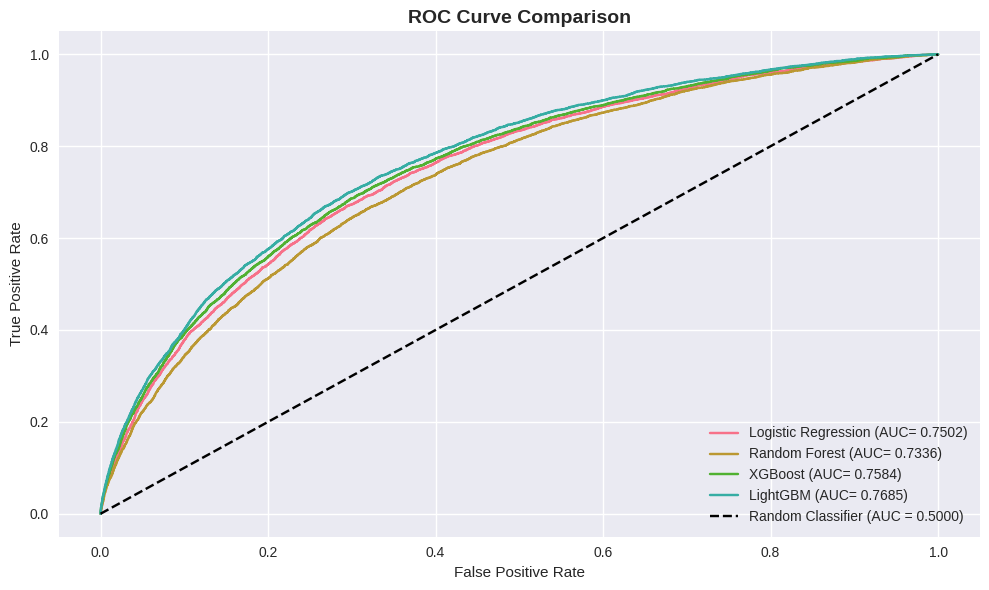

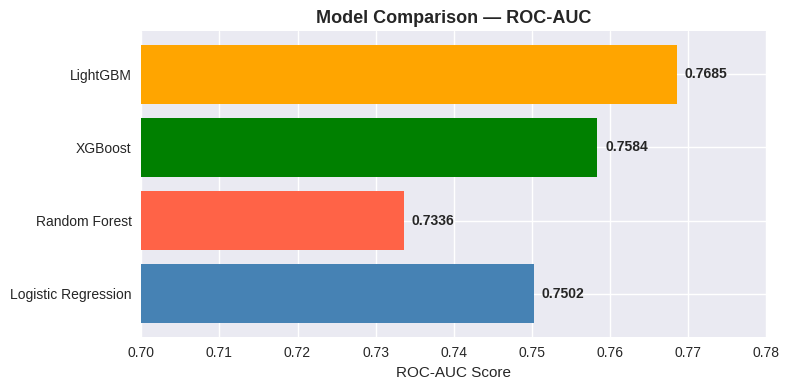

In [33]:
from sklearn.metrics import roc_curve 

# ROC-AUC scores summary
models = {
    'Logistic Regression': (lr_pred_proba, lr_auc),
    'Random Forest': (rf_pred_proba, rf_auc),
    'XGBoost': (xgb_pred_proba, xgb_auc),
    'LightGBM': (lgbm_pred_proba, lgbm_auc),
}

# Plot ROC curves
plt.figure(figsize=(10,6))

for model_name, (pred_proba, auc) in models.items():
    fpr, tpr, _ = roc_curve(y_val, pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC= {auc:.4f})')

# Random classifer baseline 
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Bar chart comparison
plt.figure(figsize=(8, 4))
model_names = list(models.keys())
auc_scores = [v[1] for v in models.values()]

bars = plt.barh(model_names, auc_scores, color=['steelblue', 'tomato', 'green', 'orange'])
plt.xlabel('ROC-AUC Score')
plt.title('Model Comparison — ROC-AUC', fontsize=13, fontweight='bold')
plt.xlim(0.70, 0.78)

for bar, score in zip(bars, auc_scores):
    plt.text(score + 0.001, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Model Interpretability (SHAP)

We use SHAP (SHapley Additive exPlanations) to understand which features 
drive the model's predictions. This is critical in banking where decisions 
must be explainable to regulators and customers.

**This section covers:**
- 5.1 Global Feature Importance — Which features matter most overall?
- 5.2 Individual Prediction Explanation — Why was this specific customer flagged?

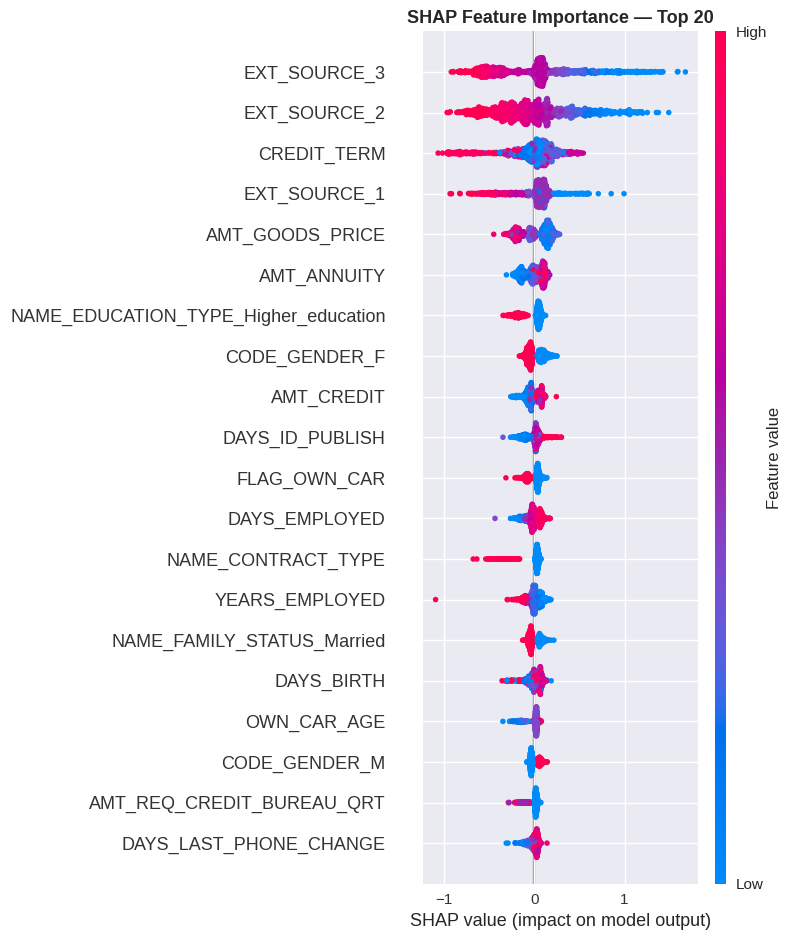

In [34]:
# 5.1 Global Feature Importance (SHAP)
import shap

# Create SHAP explainer for LightGBM
explainer = shap.TreeExplainer(lgbm_model)

# Use a sample of 1000 rows for speed
X_val_sample = X_val.iloc[:1000]
shap_values = explainer.shap_values(X_val_sample)

# For binary classification LightGBM returns list — take class 1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Summary plot — global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val_sample, max_display=20, show=False)
plt.title('SHAP Feature Importance — Top 20', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Individual Prediction Explanation

We explain why the model flagged a specific customer as high risk.

Customer ID: 103497
Predicted default probability: 76.34%
Actual outcome: Repaid


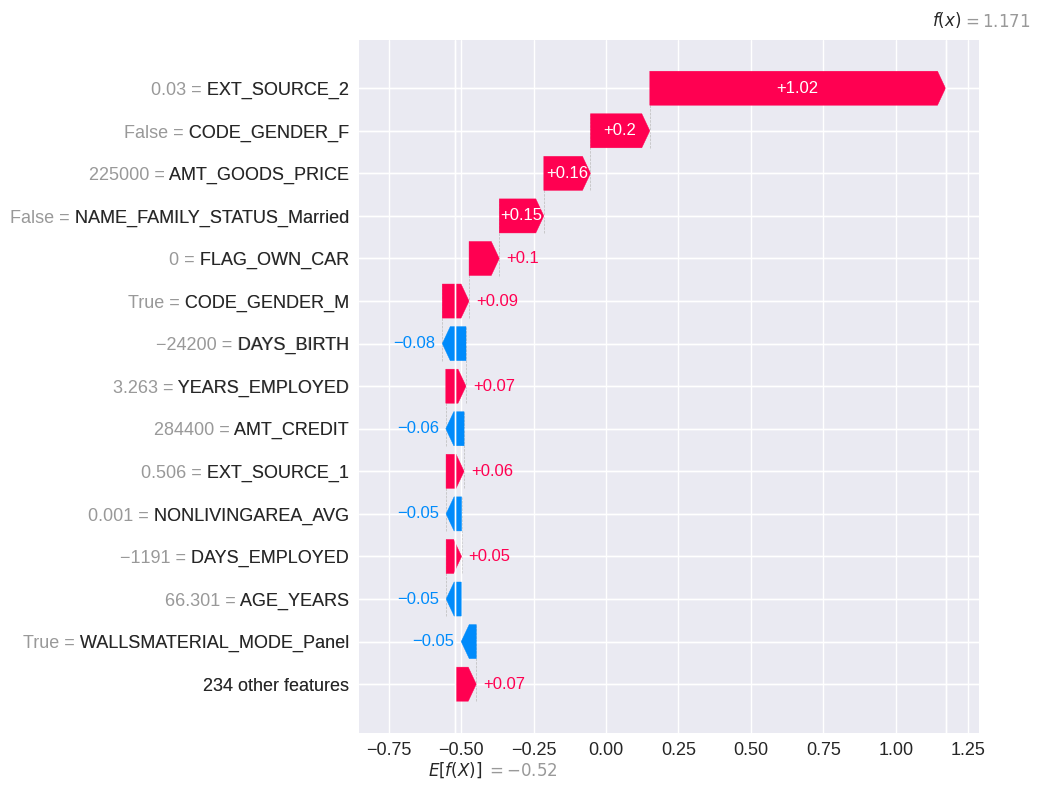

In [36]:
#  5.2 Individual Prediction Explanation 

# Find a high-risk customer from validation set
high_risk_mask = lgbm_model.predict_proba(X_val)[:, 1] > 0.7
high_risk_df = X_val[high_risk_mask].iloc[[0]]

# Convert all columns to numeric
high_risk_df = high_risk_df.apply(pd.to_numeric, errors='coerce')

customer_idx = X_val[high_risk_mask].index[0]
pred_proba = lgbm_model.predict_proba(X_val[high_risk_mask].iloc[[0]])[:, 1][0]
actual = y_val.loc[customer_idx]

print(f"Customer ID: {customer_idx}")
print(f"Predicted default probability: {pred_proba:.2%}")
print(f"Actual outcome: {'Defaulted' if actual == 1 else 'Repaid'}")

# SHAP waterfall plot
shap_values_single = explainer.shap_values(high_risk_df)

if isinstance(shap_values_single, list):
    shap_values_single = shap_values_single[1]

expected_value = explainer.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[1]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_single[0],
        base_values=expected_value,
        data=high_risk_df.iloc[0].values,
        feature_names=X_val.columns.tolist()
    ),
    max_display=15,
    show=True
)

## 6. Conclusion

**Best Model: LightGBM — ROC-AUC: 0.7685**

| Model | ROC-AUC |
|---|---|
| Logistic Regression | 0.7502 |
| Random Forest | 0.7336 |
| XGBoost | 0.7584 |
| **LightGBM** | **0.7685** |

**Key Findings:**
- EXT_SOURCE_1/2/3 are the most predictive features
- CREDIT_TERM (engineered feature) ranked Top 3 in SHAP importance
- Class imbalance (8.07%) was handled via scale_pos_weight
- Model explanations via SHAP make decisions transparent and auditable
